# PSTH Verification: Experanto Export vs DataStore

Compute trial-averaged PSTHs from the 20-trial test33 dataset to verify that the Mozaik-to-Experanto export preserves neural response structure. Compare against PSTHs computed directly from the Mozaik DataStore.

In [ ]:
import numpy as np
import json
import yaml
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from scipy import stats

# Configuration
EXPERANTO_ROOT = Path("/mnt/vast-react/projects/neural_foundation_model/mozaik_data_test33")
N_TRIALS = 20
BIN_SIZE_MS = 10        # PSTH bin width in milliseconds
PRE_STIM_MS = 100       # time before stimulus onset to include
POST_STIM_MS = 100      # time after stimulus offset to include
N_NEURONS = 20          # top-N most active neurons

# Output directory for saved arrays
OUTPUT_DIR = Path("results/psth_test33")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# DataStore PSTH results (from SLURM job)
DATASTORE_RESULTS = Path("results/psth_test33_datastore")

## 1. Parse Stimulus Table

Load `combined_meta.json` and `timestamps.npy` from trial0 (identical across all 20 trials). Build a table of 33 stimulus descriptors with onset/offset times.

In [5]:
trial0 = EXPERANTO_ROOT / "trial0"

# Load screen metadata (same for all trials)
with open(trial0 / "screen" / "combined_meta.json") as f:
    combined_meta = json.load(f)
timestamps = np.load(trial0 / "screen" / "timestamps.npy")

# Build stimulus table (skip blanks)
stimuli = []
for key in sorted(combined_meta.keys(), key=lambda x: int(x)):
    entry = combined_meta[key]
    if entry["modality"] == "blank":
        continue
    
    fi = entry["first_frame_idx"]
    onset_s = timestamps[fi]
    
    if entry["modality"] == "image":
        duration_s = entry["presentation_time"]
        offset_s = onset_s + duration_s
        stim_id = f"img_{int(entry['image_id'])}"
    elif entry["modality"] == "video":
        nf = entry["num_frames"]
        offset_s = timestamps[min(fi + nf - 1, len(timestamps) - 1)]
        duration_s = offset_s - onset_s
        stim_id = f"vid_{entry['condition_hash'][:8]}"
    
    stimuli.append({
        "key": key,
        "stim_id": stim_id,
        "modality": entry["modality"],
        "onset_s": onset_s,
        "offset_s": offset_s,
        "duration_s": duration_s,
    })

print(f"Found {len(stimuli)} stimuli: {sum(1 for s in stimuli if s['modality']=='image')} images, "
      f"{sum(1 for s in stimuli if s['modality']=='video')} videos")
for s in stimuli[:5]:
    print(f"  {s['stim_id']:20s} onset={s['onset_s']:.3f}s  offset={s['offset_s']:.3f}s  dur={s['duration_s']:.3f}s")
print("  ...")

Found 33 stimuli: 30 images, 3 videos
  img_7017             onset=0.378s  offset=0.878s  dur=0.500s
  img_4923             onset=1.400s  offset=1.900s  dur=0.500s
  img_11677            onset=2.331s  offset=2.831s  dur=0.500s
  img_123087           onset=3.241s  offset=3.741s  dur=0.500s
  img_2710             onset=4.130s  offset=4.630s  dur=0.500s
  ...


## 2. Load Experanto Spike Data (all 20 trials)

In [6]:
# Load spike data from all 20 trials: (spikes_array, spike_indices_array) per trial
trial_data = []

for t in tqdm(range(N_TRIALS), desc="Loading trials"):
    trial_dir = EXPERANTO_ROOT / f"trial{t}" / "responses"
    
    spikes = np.load(trial_dir / "spikes.npy")
    with open(trial_dir / "meta.yml") as f:
        meta = yaml.safe_load(f)
    indices = np.array(meta["spike_indices"], dtype=np.int64)
    
    trial_data.append((spikes, indices))
    
    if t == 0:
        n_neurons_total = len(indices) - 1
        print(f"Neurons: {n_neurons_total}, spike_indices length: {len(indices)}")

# Sanity check: spike counts per trial
for t, (spikes, indices) in enumerate(trial_data):
    print(f"Trial {t:2d}: {len(spikes):>10,} spikes, range [{spikes.min():.3f}, {spikes.max():.3f}]s")

Loading trials:   0%|          | 0/20 [00:00<?, ?it/s]

Loading trials:   5%|▌         | 1/20 [00:00<00:17,  1.10it/s]

Neurons: 37500, spike_indices length: 37501


Loading trials: 100%|██████████| 20/20 [00:18<00:00,  1.06it/s]

Trial  0:  6,232,517 spikes, range [0.378, 60.046]s
Trial  1:  6,231,941 spikes, range [0.378, 60.046]s
Trial  2:  6,182,186 spikes, range [0.378, 60.046]s
Trial  3:  6,205,708 spikes, range [0.378, 60.046]s
Trial  4:  6,181,194 spikes, range [0.378, 60.046]s
Trial  5:  6,224,426 spikes, range [0.378, 60.046]s
Trial  6:  6,200,707 spikes, range [0.378, 60.046]s
Trial  7:  6,222,647 spikes, range [0.378, 60.046]s
Trial  8:  6,190,737 spikes, range [0.378, 60.046]s
Trial  9:  6,228,989 spikes, range [0.378, 60.046]s
Trial 10:  6,254,719 spikes, range [0.378, 60.046]s
Trial 11:  6,233,027 spikes, range [0.378, 60.046]s
Trial 12:  6,218,899 spikes, range [0.378, 60.046]s
Trial 13:  6,183,649 spikes, range [0.378, 60.046]s
Trial 14:  6,232,067 spikes, range [0.378, 60.046]s
Trial 15:  6,184,999 spikes, range [0.378, 60.046]s
Trial 16:  6,166,082 spikes, range [0.378, 60.046]s
Trial 17:  6,205,383 spikes, range [0.378, 60.046]s
Trial 18:  6,222,057 spikes, range [0.378, 60.046]s
Trial 19:  6

## 3. Select Top-20 Most Active Neurons

Use CSR indices from trial 0 to compute spike counts per neuron (instant — no iteration needed).

In [7]:
# Compute spike count per neuron from CSR indices (trial 0)
_, indices0 = trial_data[0]
spike_counts_per_neuron = np.diff(indices0)  # indices[i+1] - indices[i] for each neuron

# Select top-N by total spike count
top_neuron_indices = np.argsort(spike_counts_per_neuron)[::-1][:N_NEURONS]
top_neuron_indices = np.sort(top_neuron_indices)  # sort by index for consistency

print(f"Top {N_NEURONS} neurons (by spike count in trial 0):")
for i, idx in enumerate(top_neuron_indices):
    print(f"  Neuron {idx:5d}: {spike_counts_per_neuron[idx]:>8,} spikes "
          f"({spike_counts_per_neuron[idx] / 60.046:.1f} Hz mean)")

# Save for shared use with DataStore PSTH script
np.save(OUTPUT_DIR / "top20_neuron_indices.npy", top_neuron_indices)
print(f"\nSaved to {OUTPUT_DIR / 'top20_neuron_indices.npy'}")

Top 20 neurons (by spike count in trial 0):
  Neuron  1188:      900 spikes (15.0 Hz mean)
  Neuron  2594:      999 spikes (16.6 Hz mean)
  Neuron  6482:      910 spikes (15.2 Hz mean)
  Neuron  8274:      977 spikes (16.3 Hz mean)
  Neuron  8983:    1,045 spikes (17.4 Hz mean)
  Neuron 11386:      930 spikes (15.5 Hz mean)
  Neuron 15689:      854 spikes (14.2 Hz mean)
  Neuron 16619:      931 spikes (15.5 Hz mean)
  Neuron 16838:      851 spikes (14.2 Hz mean)
  Neuron 18104:      898 spikes (15.0 Hz mean)
  Neuron 21208:    1,001 spikes (16.7 Hz mean)
  Neuron 21627:      905 spikes (15.1 Hz mean)
  Neuron 23253:      873 spikes (14.5 Hz mean)
  Neuron 24509:      933 spikes (15.5 Hz mean)
  Neuron 24685:      925 spikes (15.4 Hz mean)
  Neuron 25393:      893 spikes (14.9 Hz mean)
  Neuron 27226:      949 spikes (15.8 Hz mean)
  Neuron 28664:      893 spikes (14.9 Hz mean)
  Neuron 34217:      873 spikes (14.5 Hz mean)
  Neuron 37052:      860 spikes (14.3 Hz mean)

Saved to result

## 4. PSTH Computation Functions (Experanto)

Raw CSR + `np.searchsorted` for efficient per-neuron spike extraction and histogram binning.

In [8]:
def compute_stimulus_psth(trial_data, neuron_indices, onset_s, offset_s,
                          bin_size_ms=10, pre_ms=100, post_ms=100):
    """
    Compute per-neuron PSTH for one stimulus across all trials.
    
    Parameters
    ----------
    trial_data : list of (spikes, indices) tuples
        Each element is (flat spike array, CSR indices array) for one trial.
    neuron_indices : array-like
        Positional indices of neurons to include.
    onset_s, offset_s : float
        Stimulus onset and offset in seconds.
    bin_size_ms : float
        Histogram bin width in ms.
    pre_ms, post_ms : float
        Time before onset / after offset to include.
    
    Returns
    -------
    psth_matrix : (n_neurons, n_bins) mean firing rate (Hz) across trials
    sem_matrix : (n_neurons, n_bins) standard error of mean
    bin_edges_ms : (n_bins+1,) bin edges relative to stimulus onset in ms
    """
    bin_size_s = bin_size_ms / 1000.0
    pre_s = pre_ms / 1000.0
    post_s = post_ms / 1000.0
    
    window_start = onset_s - pre_s
    window_end = offset_s + post_s
    window_dur_ms = (window_end - window_start) * 1000
    n_bins = int(np.ceil(window_dur_ms / bin_size_ms))
    
    n_trials = len(trial_data)
    n_neurons = len(neuron_indices)
    
    # (n_neurons, n_trials, n_bins) — spike counts
    all_counts = np.zeros((n_neurons, n_trials, n_bins))
    
    # Bin edges relative to stimulus onset (ms)
    bin_edges_ms = np.arange(n_bins + 1) * bin_size_ms - pre_ms
    
    for trial_idx, (spikes, indices) in enumerate(trial_data):
        for ni, neuron_idx in enumerate(neuron_indices):
            # Extract this neuron's spike times from CSR
            s_start = indices[neuron_idx]
            s_end = indices[neuron_idx + 1]
            neuron_spikes = spikes[s_start:s_end]
            
            # Binary search to find spikes in the window
            lo = np.searchsorted(neuron_spikes, window_start, side='left')
            hi = np.searchsorted(neuron_spikes, window_end, side='right')
            window_spikes = neuron_spikes[lo:hi]
            
            if len(window_spikes) == 0:
                continue
            
            # Shift to relative time (ms) from stimulus onset
            rel_ms = (window_spikes - onset_s) * 1000.0
            
            counts, _ = np.histogram(rel_ms, bins=bin_edges_ms)
            all_counts[ni, trial_idx, :] = counts
    
    # Mean and SEM across trials, convert to Hz
    mean_counts = np.mean(all_counts, axis=1)
    psth_matrix = mean_counts / bin_size_s  # counts/bin -> Hz
    
    sem_counts = np.std(all_counts, axis=1, ddof=1) / np.sqrt(n_trials)
    sem_matrix = sem_counts / bin_size_s
    
    return psth_matrix, sem_matrix, bin_edges_ms


def compute_population_psth(trial_data, neuron_indices, onset_s, offset_s,
                            bin_size_ms=10, pre_ms=100, post_ms=100):
    """
    Compute population-averaged PSTH (mean across neurons and trials).
    
    Returns
    -------
    pop_psth : (n_bins,) mean firing rate (Hz)
    pop_sem : (n_bins,) SEM across neurons
    bin_edges_ms : (n_bins+1,) bin edges relative to onset in ms
    """
    # First get per-neuron PSTHs
    psth_matrix, _, bin_edges_ms = compute_stimulus_psth(
        trial_data, neuron_indices, onset_s, offset_s,
        bin_size_ms, pre_ms, post_ms
    )
    
    # Average across neurons
    pop_psth = np.mean(psth_matrix, axis=0)
    pop_sem = np.std(psth_matrix, axis=0, ddof=1) / np.sqrt(len(neuron_indices))
    
    return pop_psth, pop_sem, bin_edges_ms

## 5. Compute Experanto PSTHs for All Stimuli

In [9]:
# Compute per-neuron PSTH for each stimulus
experanto_psths = {}  # stim_id -> (psth_matrix, sem_matrix, bin_edges_ms)

for stim in tqdm(stimuli, desc="Computing Experanto PSTHs"):
    psth, sem, bins = compute_stimulus_psth(
        trial_data, top_neuron_indices,
        stim["onset_s"], stim["offset_s"],
        bin_size_ms=BIN_SIZE_MS, pre_ms=PRE_STIM_MS, post_ms=POST_STIM_MS,
    )
    experanto_psths[stim["stim_id"]] = (psth, sem, bins)

# Save results
np.savez(
    OUTPUT_DIR / "experanto_psths.npz",
    neuron_indices=top_neuron_indices,
    stim_ids=np.array([s["stim_id"] for s in stimuli]),
    **{f"{s['stim_id']}_psth": experanto_psths[s['stim_id']][0] for s in stimuli},
    **{f"{s['stim_id']}_sem": experanto_psths[s['stim_id']][1] for s in stimuli},
    **{f"{s['stim_id']}_bins": experanto_psths[s['stim_id']][2] for s in stimuli},
)
print(f"Saved Experanto PSTHs to {OUTPUT_DIR / 'experanto_psths.npz'}")

Computing Experanto PSTHs:   0%|          | 0/33 [00:00<?, ?it/s]

Computing Experanto PSTHs: 100%|██████████| 33/33 [00:00<00:00, 103.76it/s]

Saved Experanto PSTHs to results/psth_test33/experanto_psths.npz


## 6. Plot Experanto PSTHs

### 6a. Population PSTH for representative stimuli

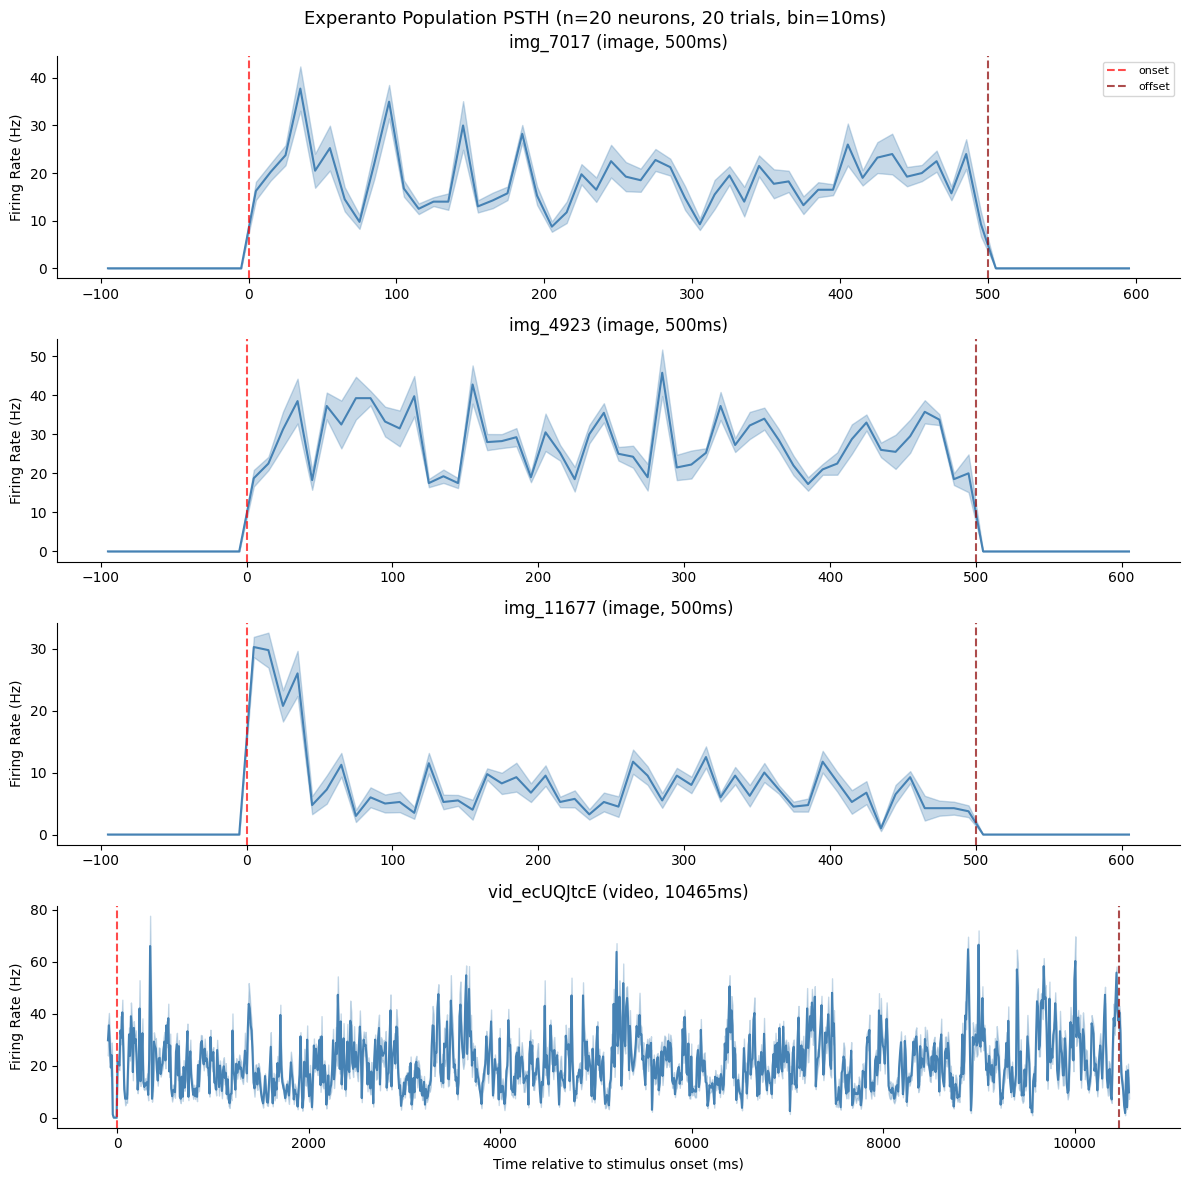

In [10]:
# Pick representative stimuli: first 3 images + first video
image_stims = [s for s in stimuli if s["modality"] == "image"][:3]
video_stims = [s for s in stimuli if s["modality"] == "video"][:1]
rep_stims = image_stims + video_stims

fig, axes = plt.subplots(len(rep_stims), 1, figsize=(12, 3 * len(rep_stims)), squeeze=False)

for i, stim in enumerate(rep_stims):
    ax = axes[i, 0]
    psth, sem, bins = experanto_psths[stim["stim_id"]]
    
    # Population average
    pop_psth = psth.mean(axis=0)
    pop_sem = psth.std(axis=0, ddof=1) / np.sqrt(len(top_neuron_indices))
    bin_centres = (bins[:-1] + bins[1:]) / 2.0
    
    ax.plot(bin_centres, pop_psth, color='steelblue', linewidth=1.5)
    ax.fill_between(bin_centres, pop_psth - pop_sem, pop_psth + pop_sem,
                    color='steelblue', alpha=0.3)
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='onset')
    ax.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.7, label='offset')
    ax.set_title(f"{stim['stim_id']} ({stim['modality']}, {stim['duration_s']*1000:.0f}ms)")
    ax.set_ylabel("Firing Rate (Hz)")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1, 0].set_xlabel("Time relative to stimulus onset (ms)")
fig.suptitle(f"Experanto Population PSTH (n={N_NEURONS} neurons, {N_TRIALS} trials, bin={BIN_SIZE_MS}ms)", fontsize=13)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "experanto_population_psth.png", dpi=200)
plt.show()

### 6b. Per-neuron PSTH grid for first image stimulus

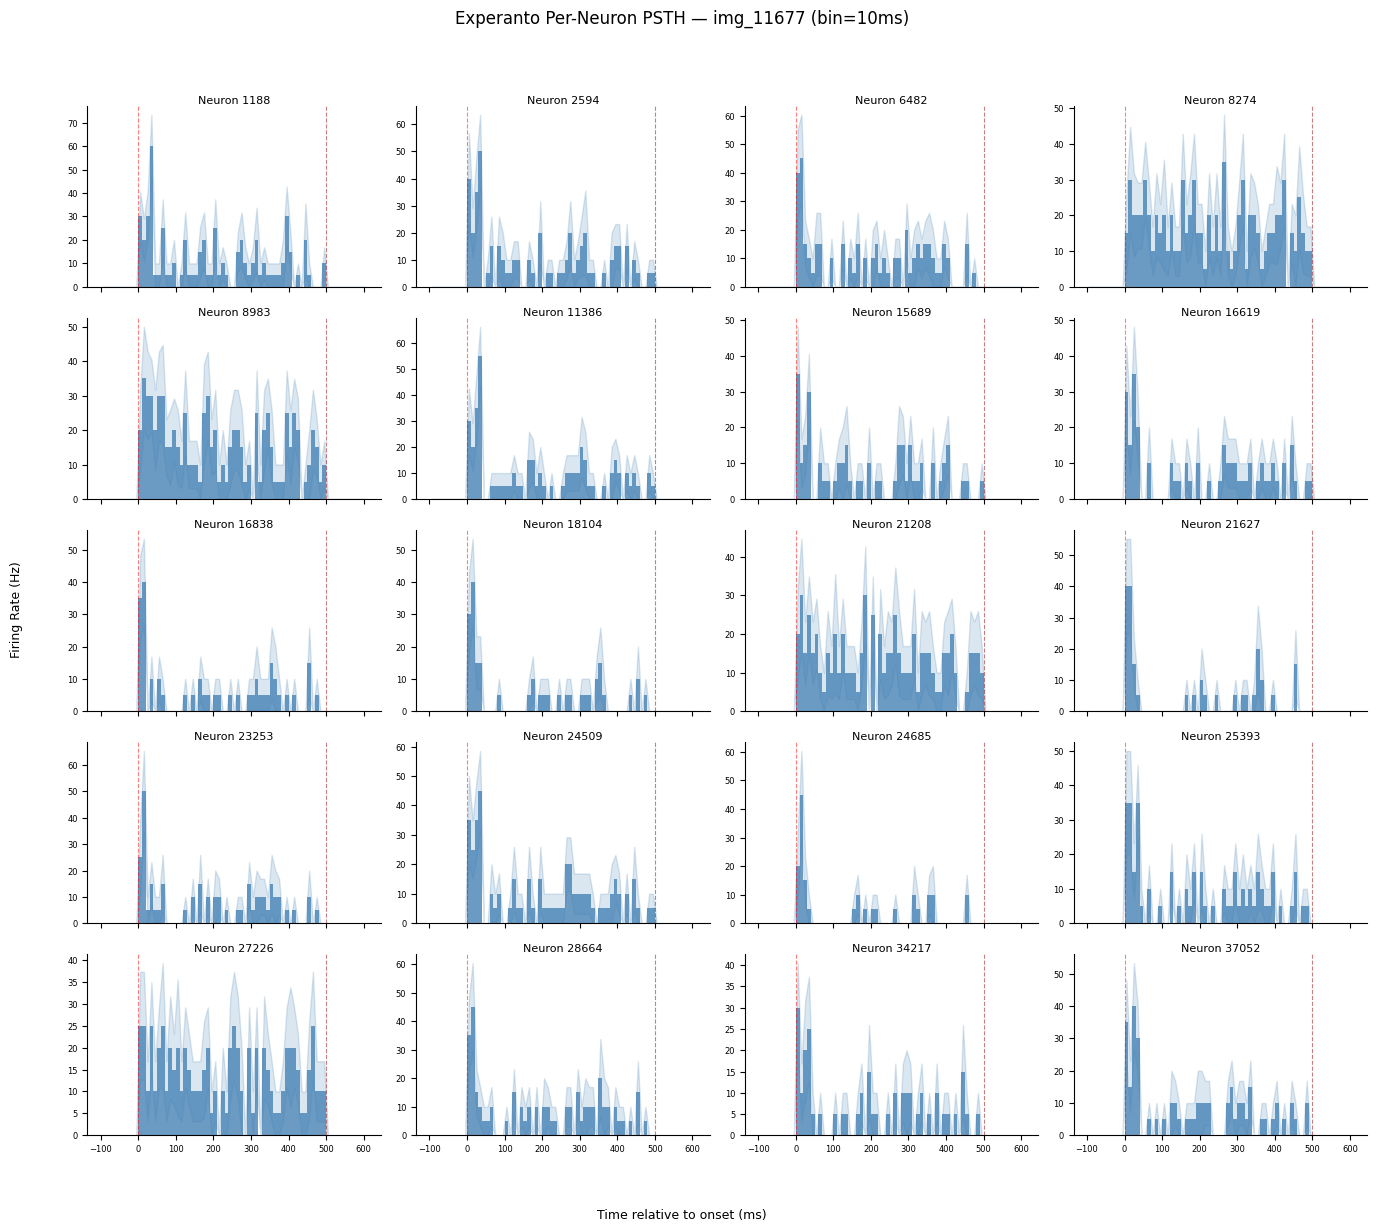

In [13]:
# Per-neuron PSTH grid for first image
stim = image_stims[2]
psth, sem, bins = experanto_psths[stim["stim_id"]]
bin_centres = (bins[:-1] + bins[1:]) / 2.0
bin_width = bins[1] - bins[0]

n_cols = 4
n_rows = int(np.ceil(N_NEURONS / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 2.5 * n_rows),
                         sharex=True)
flat_axes = axes.flatten()

for idx in range(N_NEURONS):
    ax = flat_axes[idx]
    ax.bar(bin_centres, psth[idx], width=bin_width,
           color='steelblue', edgecolor='none', alpha=0.8)
    ax.fill_between(bin_centres, psth[idx] - sem[idx], psth[idx] + sem[idx],
                    color='steelblue', alpha=0.2)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_title(f"Neuron {top_neuron_indices[idx]}", fontsize=8, pad=2)
    ax.tick_params(labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for idx in range(N_NEURONS, len(flat_axes)):
    flat_axes[idx].set_visible(False)

fig.suptitle(f"Experanto Per-Neuron PSTH — {stim['stim_id']} (bin={BIN_SIZE_MS}ms)", fontsize=12)
fig.supxlabel("Time relative to onset (ms)", fontsize=9)
fig.supylabel("Firing Rate (Hz)", fontsize=9)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.savefig(OUTPUT_DIR / "experanto_per_neuron_psth.png", dpi=200)
plt.show()

### 6c. Raster plot for one neuron, one stimulus

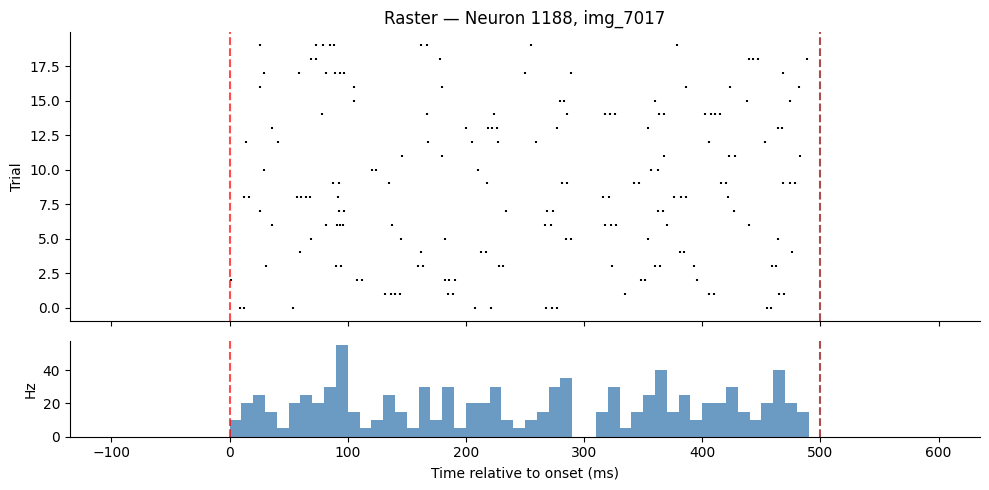

In [14]:
# Raster plot: first selected neuron, first image
stim = image_stims[0]
neuron_idx = top_neuron_indices[0]
onset = stim["onset_s"]
offset = stim["offset_s"]
pre_s = PRE_STIM_MS / 1000.0
post_s = POST_STIM_MS / 1000.0

fig, (ax_raster, ax_psth) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                                          gridspec_kw={'height_ratios': [3, 1]})

for trial_idx, (spikes, indices) in enumerate(trial_data):
    s_start = indices[neuron_idx]
    s_end = indices[neuron_idx + 1]
    neuron_spikes = spikes[s_start:s_end]
    
    lo = np.searchsorted(neuron_spikes, onset - pre_s, side='left')
    hi = np.searchsorted(neuron_spikes, offset + post_s, side='right')
    rel_ms = (neuron_spikes[lo:hi] - onset) * 1000.0
    
    ax_raster.scatter(rel_ms, np.full_like(rel_ms, trial_idx), s=1, color='black', marker='|')

ax_raster.axvline(0, color='red', linestyle='--', alpha=0.7)
ax_raster.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.7)
ax_raster.set_ylabel("Trial")
ax_raster.set_title(f"Raster — Neuron {neuron_idx}, {stim['stim_id']}")
ax_raster.spines['top'].set_visible(False)
ax_raster.spines['right'].set_visible(False)

# PSTH below
psth, sem, bins = experanto_psths[stim["stim_id"]]
bin_centres = (bins[:-1] + bins[1:]) / 2.0
ax_psth.bar(bin_centres, psth[0], width=bins[1]-bins[0],
            color='steelblue', edgecolor='none', alpha=0.8)
ax_psth.axvline(0, color='red', linestyle='--', alpha=0.7)
ax_psth.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.7)
ax_psth.set_xlabel("Time relative to onset (ms)")
ax_psth.set_ylabel("Hz")
ax_psth.spines['top'].set_visible(False)
ax_psth.spines['right'].set_visible(False)

fig.tight_layout()
plt.savefig(OUTPUT_DIR / "experanto_raster.png", dpi=200)
plt.show()

## 7. Load DataStore PSTHs and Compare

Load results from the SLURM job (`compute_psth_datastore.py`) and compare side-by-side with Experanto PSTHs.

**Run this section after the SLURM job completes.**

In [15]:
# Load DataStore PSTH results
ds_data = np.load(DATASTORE_RESULTS / "datastore_psths.npz", allow_pickle=True)
ds_stim_ids = ds_data["stim_ids"]
ds_neuron_indices = ds_data["neuron_indices"]

print(f"DataStore results: {len(ds_stim_ids)} stimuli, {len(ds_neuron_indices)} neurons")
print(f"Neuron indices match: {np.array_equal(ds_neuron_indices, top_neuron_indices)}")

DataStore results: 33 stimuli, 20 neurons
Neuron indices match: True


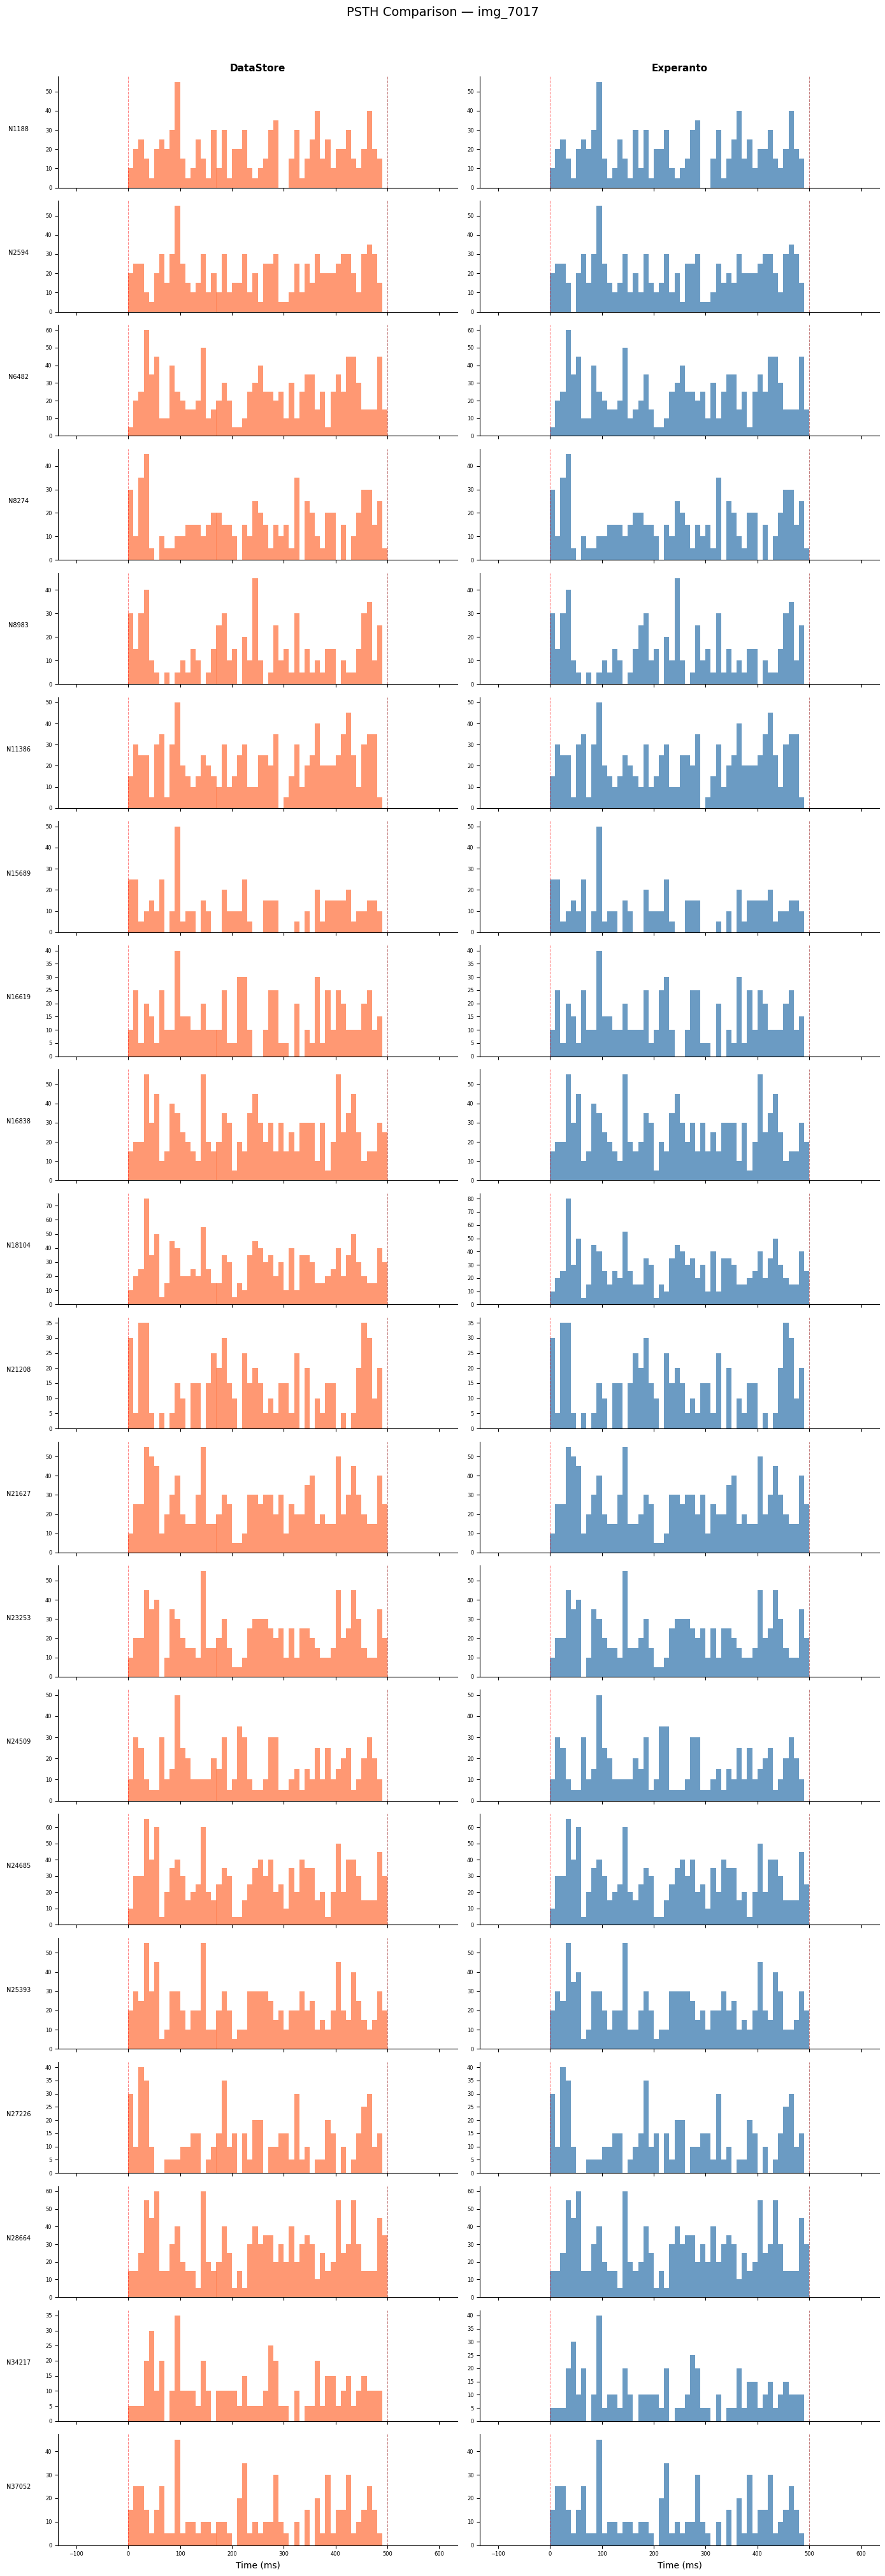

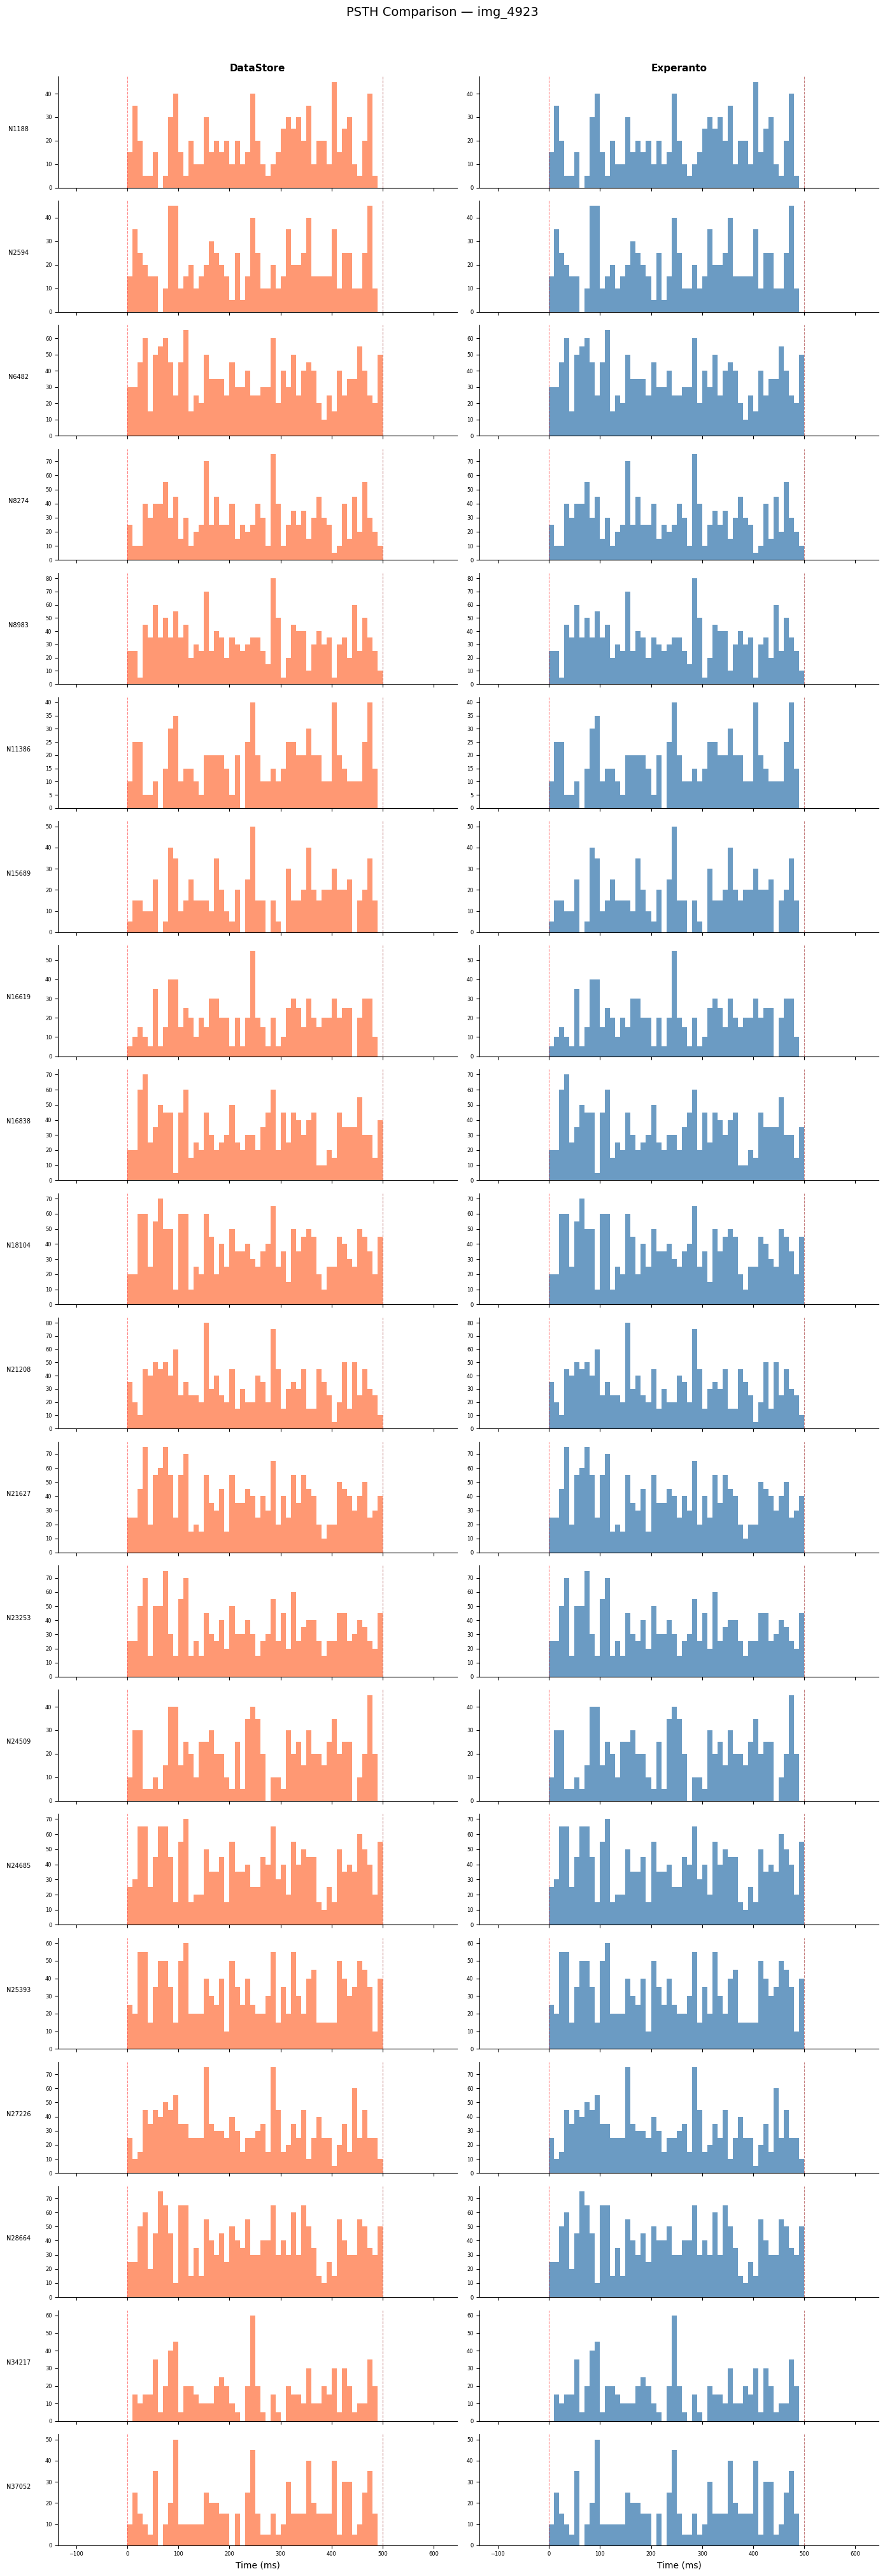

In [16]:
# Side-by-side per-neuron PSTH comparison for representative stimuli
for stim in rep_stims[:2]:  # first 2 representative stimuli
    sid = stim["stim_id"]
    
    exp_psth, exp_sem, exp_bins = experanto_psths[sid]
    ds_psth = ds_data[f"{sid}_psth"]
    ds_sem = ds_data[f"{sid}_sem"]
    ds_bins = ds_data[f"{sid}_bins"]
    
    exp_centres = (exp_bins[:-1] + exp_bins[1:]) / 2.0
    ds_centres = (ds_bins[:-1] + ds_bins[1:]) / 2.0
    
    fig, axes = plt.subplots(N_NEURONS, 2, figsize=(14, 2 * N_NEURONS), sharex=True)
    fig.suptitle(f"PSTH Comparison — {sid}", fontsize=14, y=1.01)
    
    axes[0, 0].set_title("DataStore", fontsize=11, fontweight='bold')
    axes[0, 1].set_title("Experanto", fontsize=11, fontweight='bold')
    
    for ni in range(N_NEURONS):
        # DataStore
        ax_ds = axes[ni, 0]
        ax_ds.bar(ds_centres, ds_psth[ni], width=ds_bins[1]-ds_bins[0],
                  color='coral', edgecolor='none', alpha=0.8)
        ax_ds.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
        ax_ds.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.5, linewidth=0.8)
        ax_ds.set_ylabel(f"N{top_neuron_indices[ni]}", fontsize=7, rotation=0, labelpad=30)
        ax_ds.tick_params(labelsize=6)
        ax_ds.spines['top'].set_visible(False)
        ax_ds.spines['right'].set_visible(False)
        
        # Experanto
        ax_exp = axes[ni, 1]
        ax_exp.bar(exp_centres, exp_psth[ni], width=exp_bins[1]-exp_bins[0],
                   color='steelblue', edgecolor='none', alpha=0.8)
        ax_exp.axvline(0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
        ax_exp.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.5, linewidth=0.8)
        ax_exp.tick_params(labelsize=6)
        ax_exp.spines['top'].set_visible(False)
        ax_exp.spines['right'].set_visible(False)
    
    axes[-1, 0].set_xlabel("Time (ms)")
    axes[-1, 1].set_xlabel("Time (ms)")
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / f"comparison_per_neuron_{sid}.png", dpi=150, bbox_inches='tight')
    plt.show()

### Population PSTH overlay and scatter comparison

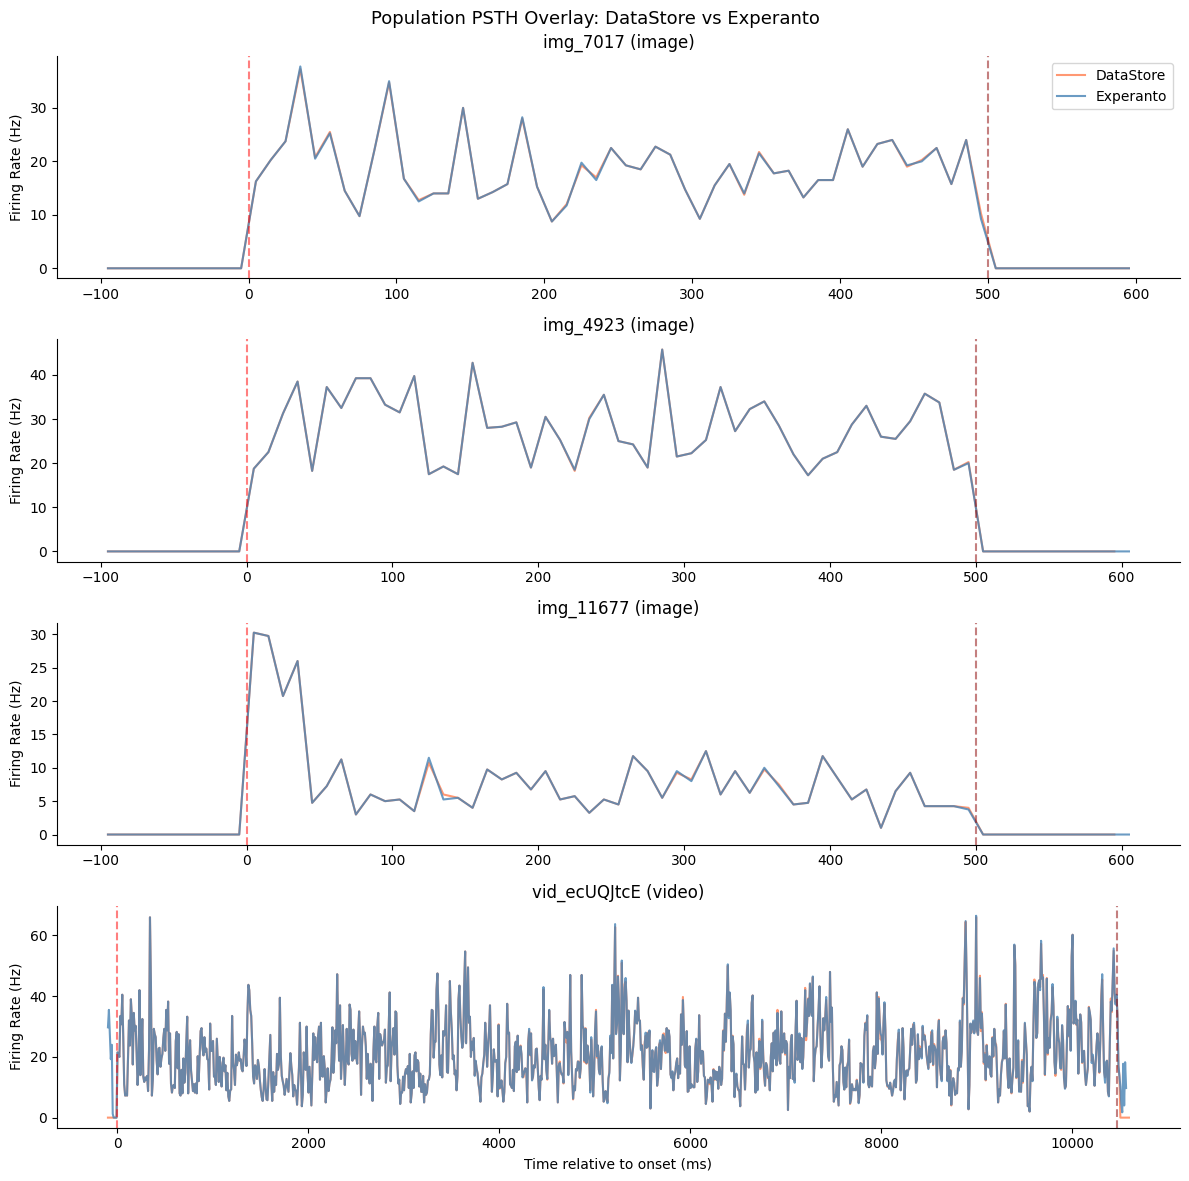

In [17]:
# Population PSTH overlay for representative stimuli
fig, axes = plt.subplots(len(rep_stims), 1, figsize=(12, 3 * len(rep_stims)), squeeze=False)

for i, stim in enumerate(rep_stims):
    ax = axes[i, 0]
    sid = stim["stim_id"]
    
    exp_psth_mat = experanto_psths[sid][0]
    exp_pop = exp_psth_mat.mean(axis=0)
    exp_bins = experanto_psths[sid][2]
    exp_centres = (exp_bins[:-1] + exp_bins[1:]) / 2.0
    
    ds_psth_mat = ds_data[f"{sid}_psth"]
    ds_pop = ds_psth_mat.mean(axis=0)
    ds_bins = ds_data[f"{sid}_bins"]
    ds_centres = (ds_bins[:-1] + ds_bins[1:]) / 2.0
    
    ax.plot(ds_centres, ds_pop, color='coral', linewidth=1.5, label='DataStore', alpha=0.8)
    ax.plot(exp_centres, exp_pop, color='steelblue', linewidth=1.5, label='Experanto', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.axvline(stim["duration_s"] * 1000, color='darkred', linestyle='--', alpha=0.5)
    ax.set_title(f"{sid} ({stim['modality']})")
    ax.set_ylabel("Firing Rate (Hz)")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i == 0:
        ax.legend()

axes[-1, 0].set_xlabel("Time relative to onset (ms)")
fig.suptitle("Population PSTH Overlay: DataStore vs Experanto", fontsize=13)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_population_overlay.png", dpi=200)
plt.show()

## 8. Summary Metrics

Stimulus                    Mean r    Min r  Max |diff| (Hz)
------------------------------------------------------------
img_7017                    0.9984   0.9900             5.00
img_4923                    0.9999   0.9993             5.00
img_11677                   0.9988   0.9936             5.00
img_123087                  0.9969   0.9848            10.00
img_2710                    0.9989   0.9968            10.00
img_8424                    0.9973   0.9929            10.00
img_4397                    0.9998   0.9976             5.00
img_10642                   0.9988   0.9923             5.00
img_11168                   0.9969   0.9923             5.00
img_2747                    0.9994   0.9956            10.00
img_7523                    0.9970   0.9865             5.00
img_126235                  0.9975   0.9913             5.00
img_4821                    0.9977   0.9927             5.00
img_10092                   0.9966   0.9905             5.00
img_11288               

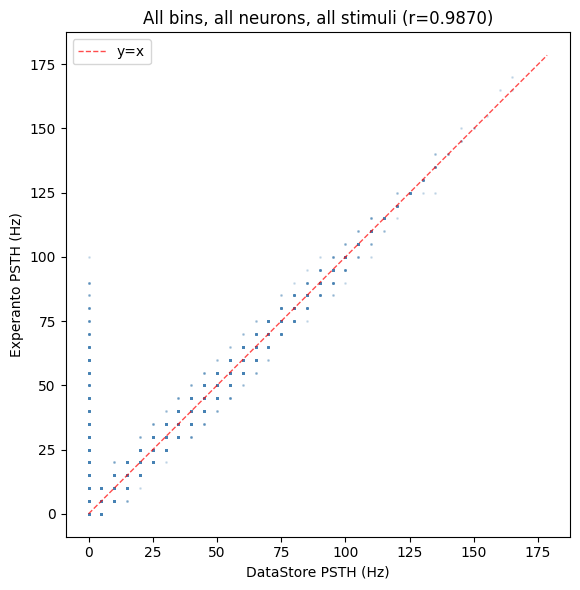

In [18]:
# Quantitative comparison: per-neuron correlation and max absolute difference
print(f"{'Stimulus':25s} {'Mean r':>8s} {'Min r':>8s} {'Max |diff| (Hz)':>16s}")
print("-" * 60)

all_exp_vals = []
all_ds_vals = []

for stim in stimuli:
    sid = stim["stim_id"]
    exp_psth = experanto_psths[sid][0]
    ds_psth = ds_data[f"{sid}_psth"]
    
    # Truncate to common length (should match, but be safe)
    n_bins = min(exp_psth.shape[1], ds_psth.shape[1])
    exp_flat = exp_psth[:, :n_bins].ravel()
    ds_flat = ds_psth[:, :n_bins].ravel()
    
    all_exp_vals.append(exp_flat)
    all_ds_vals.append(ds_flat)
    
    # Per-neuron correlations
    corrs = []
    for ni in range(N_NEURONS):
        e = exp_psth[ni, :n_bins]
        d = ds_psth[ni, :n_bins]
        if np.std(e) > 0 and np.std(d) > 0:
            r, _ = stats.pearsonr(e, d)
            corrs.append(r)
    
    max_diff = np.max(np.abs(exp_flat - ds_flat))
    mean_r = np.mean(corrs) if corrs else float('nan')
    min_r = np.min(corrs) if corrs else float('nan')
    
    print(f"{sid:25s} {mean_r:8.4f} {min_r:8.4f} {max_diff:16.2f}")

# Overall scatter
all_exp = np.concatenate(all_exp_vals)
all_ds = np.concatenate(all_ds_vals)
overall_r, _ = stats.pearsonr(all_exp, all_ds)
print(f"\n{'Overall correlation':25s} {overall_r:8.4f}")
print(f"{'Overall max |diff|':25s} {'':8s} {np.max(np.abs(all_exp - all_ds)):16.2f} Hz")

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(all_ds, all_exp, s=1, alpha=0.2, color='steelblue')
lim = max(all_ds.max(), all_exp.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, alpha=0.7, label='y=x')
ax.set_xlabel("DataStore PSTH (Hz)")
ax.set_ylabel("Experanto PSTH (Hz)")
ax.set_title(f"All bins, all neurons, all stimuli (r={overall_r:.4f})")
ax.set_aspect('equal')
ax.legend()
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "comparison_scatter.png", dpi=200)
plt.show()